# Case Study

Outline:

The attached Excel file contains information regarding the industry exposures of an actual long-short equity portfolio manager through 2016. Specifically, the file contain industry exposures, industry GMVs and industry factor returns. 

Note: “GMV” is gross market value of the portfolio by industry. Industry expsoures are net industry exposures of the portfolio. Both are end of day exposure measures.

Objective:
Evaluate the portfolio manager’s industry risk taking.
1.	Use both Industry Exposures and Industry Factor Returns provided to calculate the Industry PnL for portfolio. 
2.	Assess the performance of different Industries in terms of risk rewards. i.e. evaluation should consider analysis of risk, performance and skill in industry risk taking.

Output:
Write up your findings and supply all supporting Python code (ie any analysis or visualizations referred to in the text should be reproducible from your supplied code). If you choose to use any additional data, include that as well.

Include a top level summary that will be used to share your findings with senior management regarding the industry risk taking ability of this portfolio manager for the year, including any actionable recommendations or further analysis you’d propose to conduct as next steps.

## Set Up

In [58]:
#import needed packages
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns

## Data loading

Implementation notes:
- Loaded the files and performed basic data exploration to understand data.

In [2]:
# file path
file_path = 'IndustryAbility.2016CaseData.xlsx'

In [3]:
# Load the Excel file to examine its content
excel_data = pd.ExcelFile(file_path)

# Display sheet names to understand the structure
sheet_names = excel_data.sheet_names
sheet_names

['Industry Exposures', 'Industry GMVs', 'Industry Factor Returns']

In [4]:
# Load each sheet to explore the data
industry_exposures = pd.read_excel(file_path, sheet_name='Industry Exposures')
industry_gmvs = pd.read_excel(file_path, sheet_name='Industry GMVs')
industry_factor_returns = pd.read_excel(file_path, sheet_name='Industry Factor Returns')

# Display the first few rows of each sheet to understand their structure and content
industry_exposures.head(), industry_gmvs.head(), industry_factor_returns.head()

(        Date                                        Industry  Exposure
 0 2016-01-04                                       Chemicals  0.015615
 1 2016-01-04  Electronic Equipment, Instruments & Components  0.007849
 2 2016-01-04                        Food & Staples Retailing -0.003160
 3 2016-01-04                                   Food Products -0.015710
 4 2016-01-04                   Hotels, Restaurants & Leisure -0.018941,
         Date                                        Industry       GMV
 0 2016-01-04                                       Chemicals  0.015615
 1 2016-01-04  Electronic Equipment, Instruments & Components  0.007849
 2 2016-01-04                        Food & Staples Retailing  0.036494
 3 2016-01-04                                   Food Products  0.015710
 4 2016-01-04                   Hotels, Restaurants & Leisure  0.177251,
         Date                          Industry  DailyReturn
 0 2016-01-04                   Auto Components     0.001218
 1 2016-01-0

In [5]:
print(industry_factor_returns.isna().sum())
print((industry_factor_returns == 0).sum())

Date           0
Industry       0
DailyReturn    0
dtype: int64
Date             0
Industry         0
DailyReturn    252
dtype: int64


## Industry Factor PnL

Key take aways from analysis:
- The PM industry factor exposure contributed positively to returns, however with significant volatility. 
- Observed significant two periods of drawdowns and volatile sharpe signal room for PM improvement on his execution.
- Most of top pnl industry contribution is found from shorted industries while lossess from long exposure was offset by timily timing of Airlines industry bottom.

Implementation Notes:
- Multiplied industry exposure by lagged industry returns to prevent for hindsight bias. 
- Indentified top and bottom pnl contributors followed by their average exposure across the sample period.
- Calculated and displayed risk return profile statistics: Drawdown, Sharpe, and Skew.  

In [6]:
# Merge Industry Exposures and Industry Factor Returns on Date and Industry
industry_pnl = pd.merge(industry_exposures, industry_factor_returns, on=['Date', 'Industry'], how='left')

# Shift the DailyReturn by one day to get the "next day's return" for each industry
industry_pnl['Next_Day_Return'] = industry_pnl.groupby('Industry')['DailyReturn'].shift(-1)

# Calculate Industry PnL: PnL = Exposure * Next Day's Return
industry_pnl['Industry_PnL'] = industry_pnl['Exposure'] * industry_pnl['Next_Day_Return']

# Display the result
industry_pnl

,Date,Industry,Exposure,DailyReturn,Next_Day_Return,Industry_PnL
0,2016-01-04,Chemicals,0.015615,-0.000309,-0.004883,-0.000076
1,2016-01-04,"Electronic Equipment, Instruments & Components",0.007849,-0.002679,-0.007839,-0.000062
2,2016-01-04,Food & Staples Retailing,-0.003160,0.001162,0.004610,-0.000015
3,2016-01-04,Food Products,-0.015710,0.000859,0.000646,-0.000010
4,2016-01-04,"Hotels, Restaurants & Leisure",-0.018941,-0.003321,0.002743,-0.000052
...,...,...,...,...,...,...
13011,2016-12-30,Specialty Retail,0.001684,-0.002098,NaN,NaN
13012,2016-12-30,"Textiles, Apparel & Luxury Goods",0.000845,0.000971,NaN,NaN
13013,2016-12-30,Tobacco,-0.000301,0.000620,NaN,NaN
13014,2016-12-30,Trading Companies & Distributors,-0.000033,-0.002870,NaN,NaN


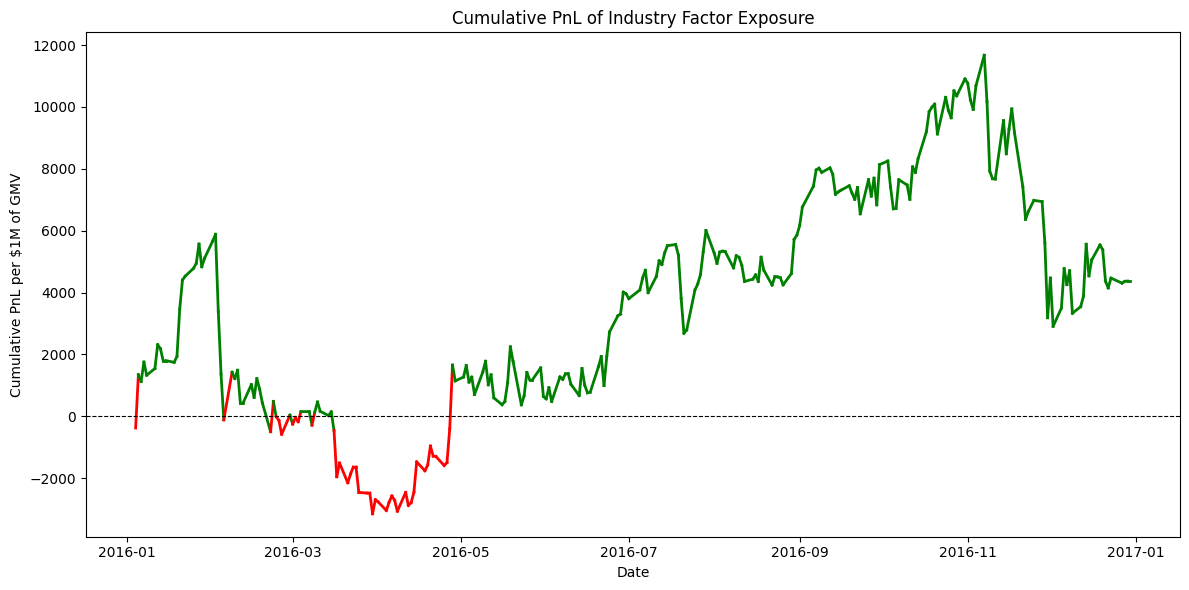

In [7]:
# Sum the returns for each date in industry_factor_returns to get the total return for each period
industry_total_pnl = industry_pnl.groupby('Date')['Industry_PnL'].sum().reset_index() 

# Calculate cumulative pnl
industry_total_pnl['Cumulative_pnl'] = industry_total_pnl['Industry_PnL'].cumsum() * 1000000

# Determine line color: green for positive values, red for negative
line_colors = ['green' if pnl >= 0 else 'red' for pnl in industry_total_pnl['Cumulative_pnl']]

# Plot the cumulative performance
plt.figure(figsize=(12, 6))

# Plot line with dynamic coloring
for i in range(len(industry_total_pnl) - 1):
    plt.plot(
        industry_total_pnl['Date'][i:i+2],
        industry_total_pnl['Cumulative_pnl'][i:i+2],
        color=line_colors[i],
        linewidth=2
    )

plt.title('Cumulative PnL of Industry Factor Exposure')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL per $1M of GMV')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


In [8]:
# pnl contribution
# Summarize Industry PnL to understand total PnL by industry over the sample period
industry_pnl_summary = industry_pnl.groupby('Industry')['Industry_PnL'].sum().reset_index()

# Sort the Industry PnL summary to get the top n and bottom n industries by PnL
n = 5
top_pnl = industry_pnl_summary.sort_values(by='Industry_PnL', ascending=False).head(n)
bottom_pnl = industry_pnl_summary.sort_values(by='Industry_PnL', ascending=True).head(n)

# Calculate average exposure for each industry during the sample period
average_exposure = industry_exposures.groupby('Industry')['Exposure'].mean().reset_index()

# Merge the average exposure with top and bottom 20 PnL industries
top_pnl = top_pnl.merge(average_exposure, on='Industry', how='left')
bottom_pnl = bottom_pnl.merge(average_exposure, on='Industry', how='left')


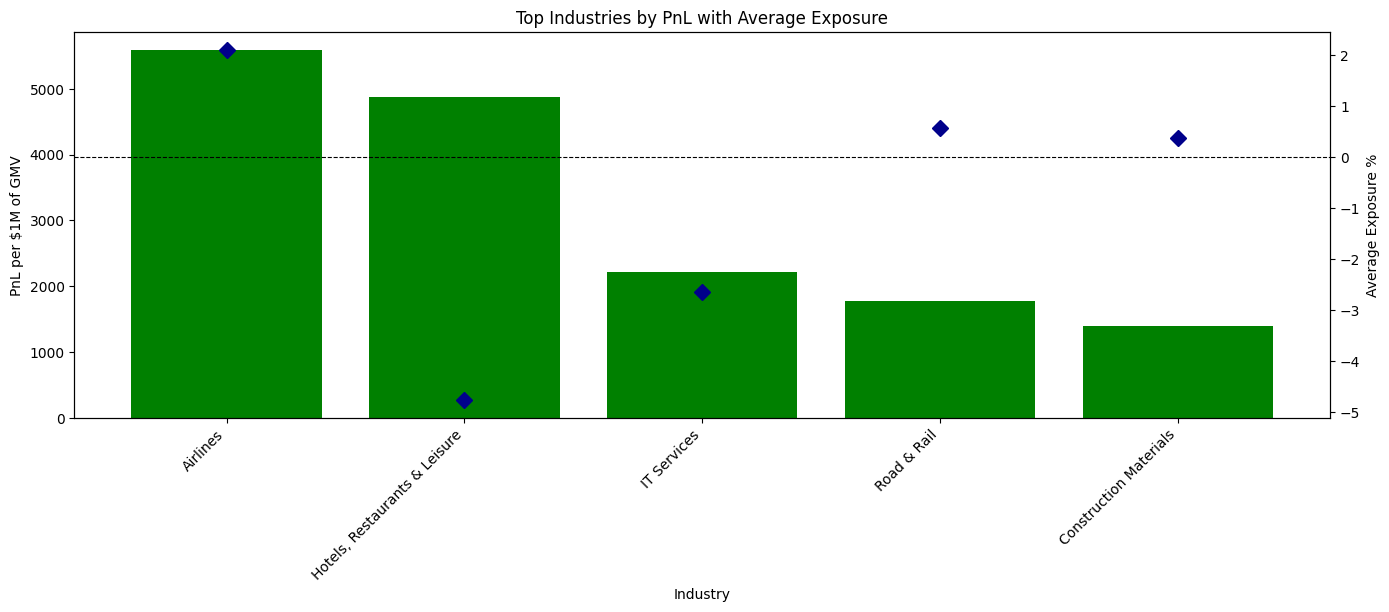

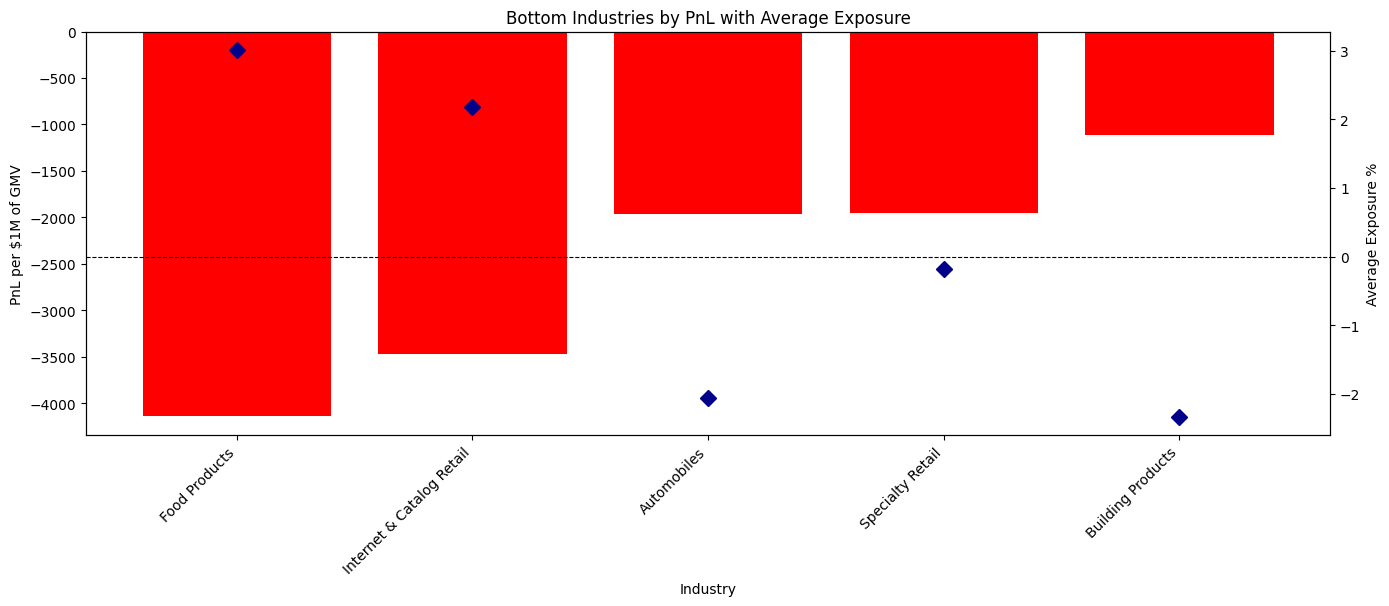

In [9]:
# Plotting the top industries by PnL
fig, ax1 = plt.subplots(figsize=(14, 6))

# PnL Bar Plot
ax1.bar(top_pnl['Industry'], top_pnl['Industry_PnL'] * 1000000, color='green', label='PnL')
ax1.set_xlabel('Industry')
ax1.set_ylabel('PnL per $1M of GMV', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Set explicit ticks and labels for x-axis
ax1.set_xticks(range(len(top_pnl['Industry'])))
ax1.set_xticklabels(top_pnl['Industry'], rotation=45, ha='right')

# Secondary axis for average exposure
ax2 = ax1.twinx()
ax2.plot(range(len(top_pnl['Industry'])), top_pnl['Exposure'] * 100, 'D', color='darkblue', markersize=8, label='Average Exposure')  # Changed to yellow diamonds
ax2.set_ylabel('Average Exposure %', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add a dashed black line at the 0 level of the secondary y-axis
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)

fig.tight_layout()
plt.title('Top Industries by PnL with Average Exposure')
plt.show()

# Plotting the bottom industries by PnL
fig, ax1 = plt.subplots(figsize=(14, 6))

# PnL Bar Plot
ax1.bar(bottom_pnl['Industry'], bottom_pnl['Industry_PnL'] * 1000000, color='red', label='PnL')
ax1.set_xlabel('Industry')
ax1.set_ylabel('PnL per $1M of GMV', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Set explicit ticks and labels for x-axis
ax1.set_xticks(range(len(bottom_pnl['Industry'])))
ax1.set_xticklabels(bottom_pnl['Industry'], rotation=45, ha='right')

# Secondary axis for average exposure
ax2 = ax1.twinx()
ax2.plot(range(len(bottom_pnl['Industry'])), bottom_pnl['Exposure'] * 100, 'D', color='darkblue', markersize = 8,label='Average Exposure')  # Changed to yellow diamonds
ax2.set_ylabel('Average Exposure %', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add a dashed black line at the 0 level of the secondary y-axis
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)

fig.tight_layout()
plt.title('Bottom Industries by PnL with Average Exposure')
plt.show()


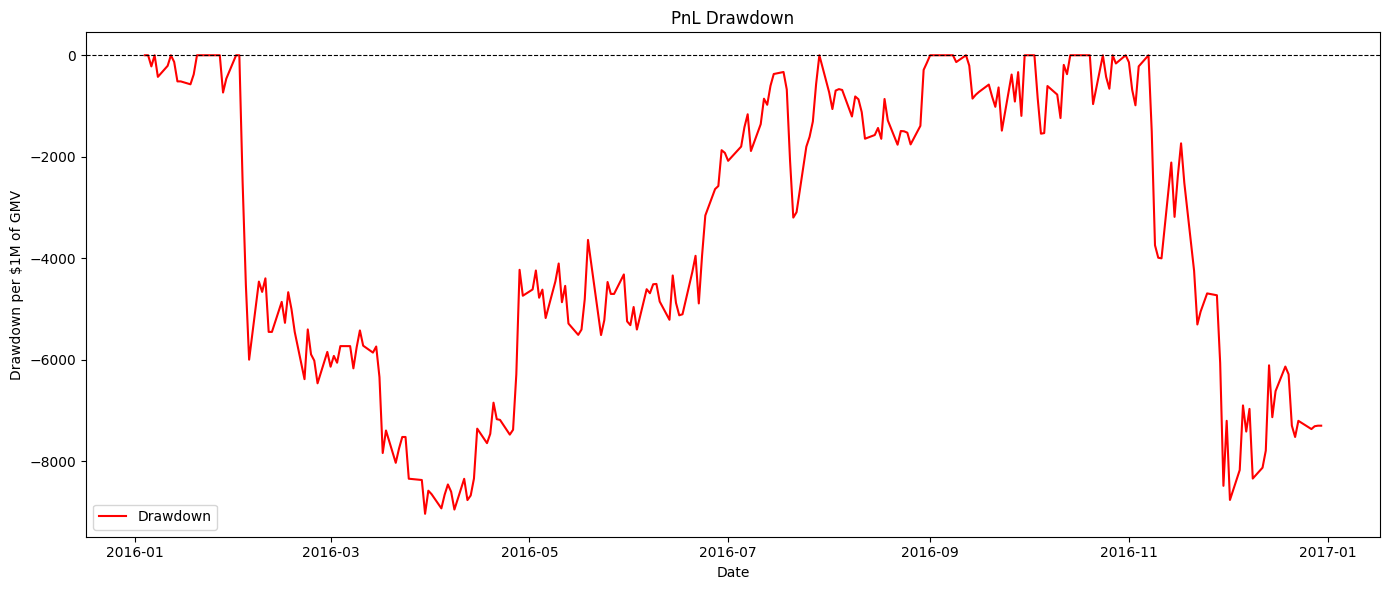

In [10]:
# Calculate the drawdown from the cumulative PnL
industry_total_pnl['Peak_Cumulative_PnL'] = industry_total_pnl['Cumulative_pnl'].cummax()
industry_total_pnl['Drawdown'] = (industry_total_pnl['Cumulative_pnl'] - industry_total_pnl['Peak_Cumulative_PnL'])

# Plot the drawdown across the time series
plt.figure(figsize=(14, 6))
plt.plot(industry_total_pnl['Date'], industry_total_pnl['Drawdown'], color='red', label='Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown per $1M of GMV')
plt.title('PnL Drawdown')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()


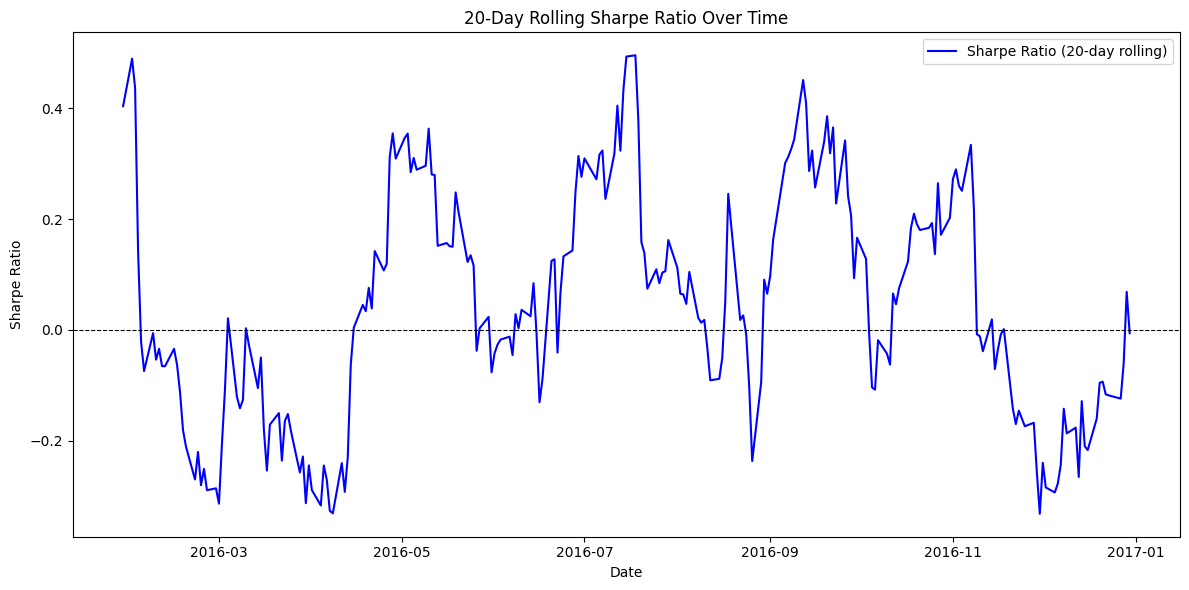

In [11]:
# Calculate the rolling Sharpe ratio using a 20-day lookback period
rolling_period = 20

# Calculate daily mean and standard deviation of PnL over the rolling period
industry_total_pnl['Rolling_Mean'] = industry_total_pnl['Industry_PnL'].rolling(window=rolling_period).mean()
industry_total_pnl['Rolling_StdDev'] = industry_total_pnl['Industry_PnL'].rolling(window=rolling_period).std()

# Calculate the Sharpe ratio
industry_total_pnl['Sharpe_Ratio'] = (
    industry_total_pnl['Rolling_Mean'] / industry_total_pnl['Rolling_StdDev']
)

# Plot the Sharpe ratio over time
plt.figure(figsize=(12, 6))
plt.plot(industry_total_pnl['Date'], industry_total_pnl['Sharpe_Ratio'], color='blue', label='Sharpe Ratio (20-day rolling)')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.title('20-Day Rolling Sharpe Ratio Over Time')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# Calculate required metrics
average_pnl = industry_total_pnl['Industry_PnL'].mean() * 1000000
std_dev_pnl = industry_total_pnl['Industry_PnL'].std() * 1000000
sharpe = average_pnl / std_dev_pnl
skew_pnl = industry_total_pnl['Industry_PnL'].skew()
max_drawdown = industry_total_pnl['Drawdown'].min() #* 1000000
sample_size = len(industry_total_pnl)

# Create a summary table with formatted values (rounded to 2 decimals)
summary_table = pd.DataFrame({
    'Metric': ['Average PnL', 'Standard Deviation', 'Sharpe', 'Skew', 'Maximum Drawdown', 'Sample Size'],
    'Value': [
        round(average_pnl, 2),
        round(std_dev_pnl, 2),
        round(sharpe, 2),
        round(skew_pnl, 2),
        round(max_drawdown, 2),
        sample_size
    ]
})

# Disable scientific notation for display
pd.set_option('display.float_format', '{:.2f}'.format)

# Print the summary table
print(summary_table)


               Metric    Value
0         Average PnL    17.08
1  Standard Deviation   705.10
2              Sharpe     0.02
3                Skew    -0.42
4    Maximum Drawdown -9033.62
5         Sample Size   256.00


## Industry Risk Taking Analysis

Key Takeaways:
- PM will benefit from equally sizing industry exposures since equal-sized book analysis exhibits higher sharpes than actual exposures on both long, short, and long short basis.
- PM demostrate superior timing skills on short exposures signaling replicable skill in adentifying shorts. 
- Overall, PM will benefit from making long exposures more uniform and reflecting on his short decision to confirm timing skill.   

Implementation notes:
- Perform cross-sectional-equalized strategy to analyze sizing skills
- Perform cross-sectional-time-size-equalized straegy to analyze toming skills

In [13]:
# Step 1: Merge industry_exposures and industry_gmv on 'Date' and 'Industry'
merged_data = pd.merge(industry_exposures, industry_gmvs, on=['Date', 'Industry'], how='inner')

# Step 2: Subset the top 10 rows by 'Industry_GMV' for each date
top_10_gmv_per_date = (
    merged_data.sort_values(['Date', 'GMV'], ascending=[True, False])
    .groupby('Date')
    .head(10)
)

# Step 3: Add 'adjusted_exposure' column
top_10_gmv_per_date['Adjusted_Exposure'] = (
    top_10_gmv_per_date.groupby('Date')['Exposure'].transform(lambda x: (x.abs().sum() / 10) * x / x.abs())
)

# Step 4: Merge with industry_factor_returns and lag returns by one day
top_10_gmv_per_date = pd.merge(
    top_10_gmv_per_date,
    industry_factor_returns,
    on=['Date', 'Industry'],
    how='left'
)
top_10_gmv_per_date['Lagged_Return'] = top_10_gmv_per_date.groupby('Industry')['DailyReturn'].shift(-1)

# Step 5: Separate data into long, long & short, and short categories
long_data = top_10_gmv_per_date[top_10_gmv_per_date['Adjusted_Exposure'] > 0]
short_data = top_10_gmv_per_date[top_10_gmv_per_date['Adjusted_Exposure'] < 0]
long_and_short_data = top_10_gmv_per_date 

In [14]:
long_and_short_data.head(10)

,Date,Industry,Exposure,GMV,Adjusted_Exposure,DailyReturn,Lagged_Return
0,2016-01-04,Internet & Catalog Retail,-0.01,0.20,-0.03,-0.01,-0.01
1,2016-01-04,Internet Software & Services,0.05,0.18,0.03,-0.01,-0.01
2,2016-01-04,"Hotels, Restaurants & Leisure",-0.02,0.18,-0.03,-0.00,0.00
3,2016-01-04,"Textiles, Apparel & Luxury Goods",0.06,0.10,0.03,0.01,0.01
4,2016-01-04,Multiline Retail,0.01,0.09,0.03,0.02,0.01
5,2016-01-04,Specialty Retail,-0.06,0.06,-0.03,0.01,0.01
6,2016-01-04,IT Services,0.03,0.04,0.03,-0.01,-0.00
7,2016-01-04,Food & Staples Retailing,-0.00,0.04,-0.03,0.00,0.00
8,2016-01-04,Personal Products,-0.03,0.03,-0.03,0.01,-0.00
9,2016-01-04,Media,0.02,0.02,0.03,-0.01,-0.01


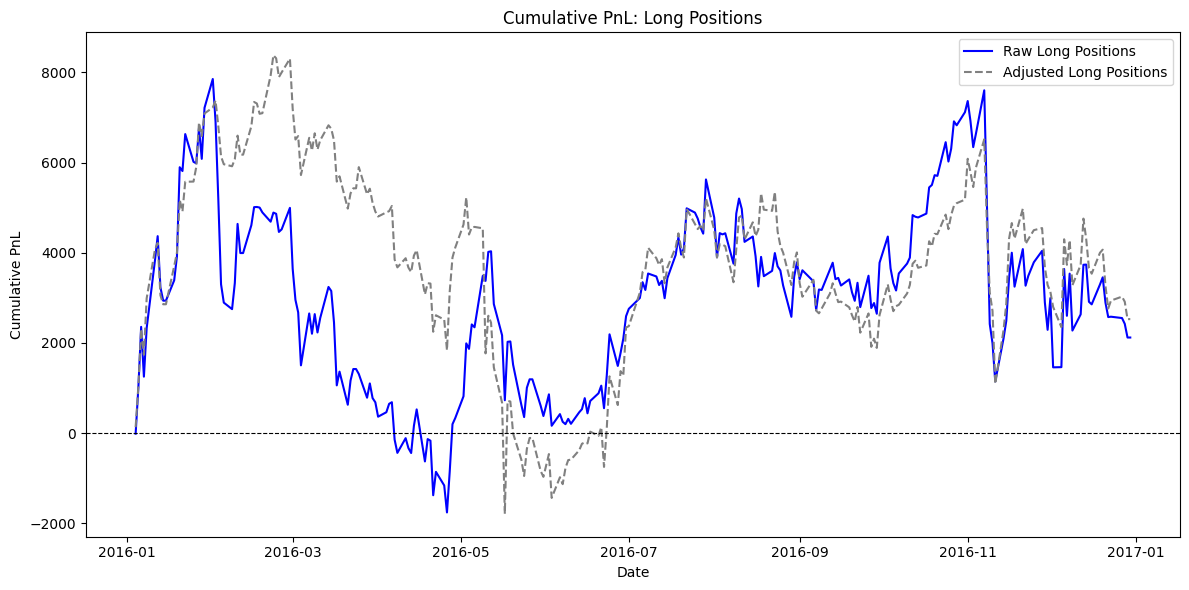

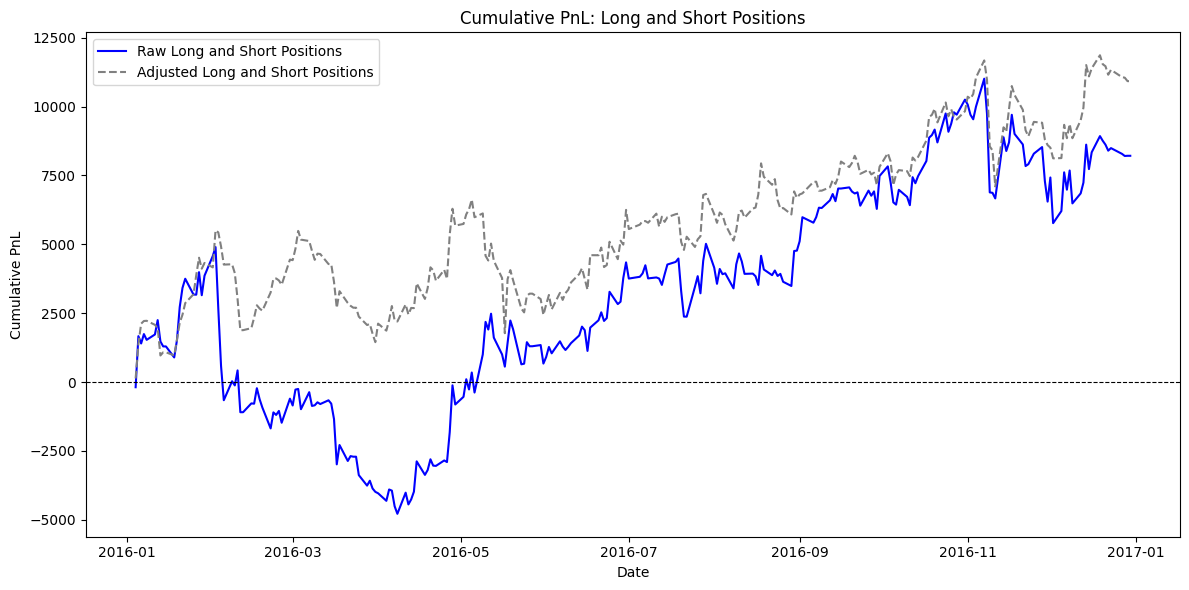

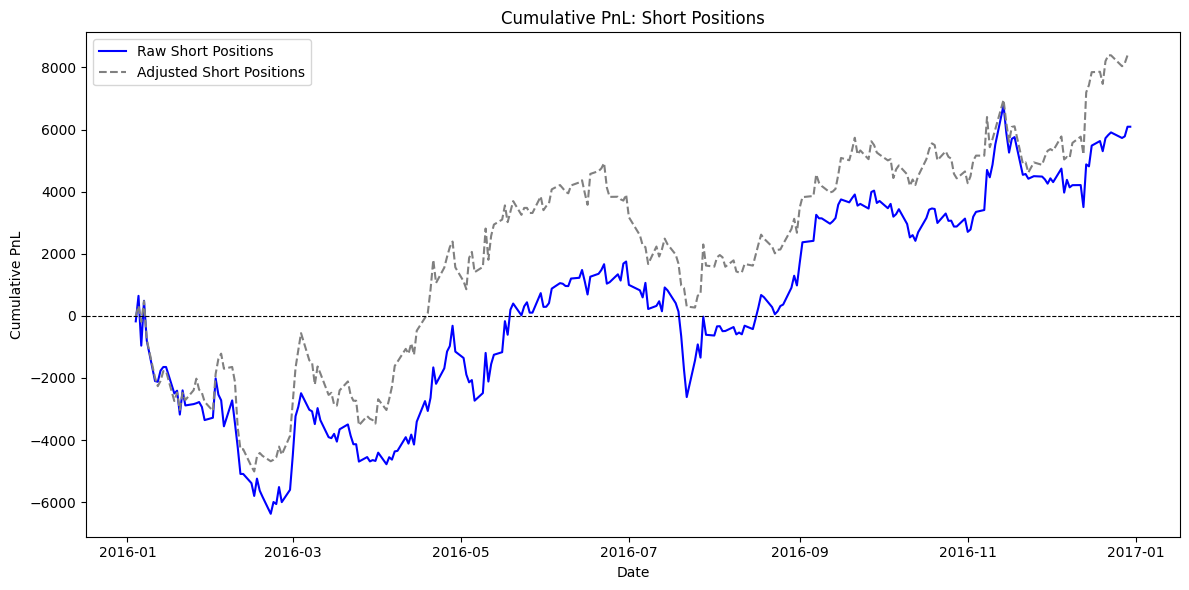

In [15]:
# Step 6: Plot cumulative PnL for each category

# Helper function to calculate and plot cumulative PnL
def plot_cumulative_pnl(data, title, color):
    data = data.copy()
    
    data['PnL_raw'] = data['Exposure'] * data['Lagged_Return']
    data['PnL_eq'] = data['Adjusted_Exposure'] * data['Lagged_Return']
    
    cumulative_pnl_raw = data.groupby('Date')['PnL_raw'].sum().cumsum() * 1000000
    cumulative_pnl_eq = data.groupby('Date')['PnL_eq'].sum().cumsum() * 1000000
    
    # Plot both cumulative PnL series
    plt.figure(figsize=(12, 6))
    plt.plot(cumulative_pnl_raw.index, cumulative_pnl_raw.values, color='blue', label=f'Raw {title}')
    plt.plot(cumulative_pnl_eq.index, cumulative_pnl_eq.values, color=color, linestyle='--', label=f'Adjusted {title}')
    plt.title(f'Cumulative PnL: {title}')
    plt.xlabel('Date')
    plt.ylabel('Cumulative PnL')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot cumulative PnL for each category
plot_cumulative_pnl(long_data, 'Long Positions', 'grey')
plot_cumulative_pnl(long_and_short_data, 'Long and Short Positions', 'grey')
plot_cumulative_pnl(short_data, 'Short Positions', 'grey')


In [38]:
# Helper to compute Sharpe ratio
def sharpe_ratio(series):
    mean_return = series.mean()
    std_dev = series.std()
    return mean_return / std_dev if std_dev != 0 else 0

# Create copies of the data to avoid SettingWithCopyWarning
long_data = long_data.copy()
short_data = short_data.copy()
long_and_short_data = long_and_short_data.copy()

# Calculate raw and adjusted PnL for each category
long_data['PnL_raw'] = long_data['Exposure'] * long_data['Lagged_Return']
long_data['PnL_adj'] = long_data['Adjusted_Exposure'] * long_data['Lagged_Return']

short_data['PnL_raw'] = short_data['Exposure'] * short_data['Lagged_Return']
short_data['PnL_adj'] = short_data['Adjusted_Exposure'] * short_data['Lagged_Return']

long_and_short_data['PnL_raw'] = long_and_short_data['Exposure'] * long_and_short_data['Lagged_Return']
long_and_short_data['PnL_adj'] = long_and_short_data['Adjusted_Exposure'] * long_and_short_data['Lagged_Return']

# Calculate Sharpe ratios
sharpe_long_raw = sharpe_ratio(long_data['PnL_raw'])
sharpe_long_adj = sharpe_ratio(long_data['PnL_adj'])

sharpe_short_raw = sharpe_ratio(short_data['PnL_raw'])
sharpe_short_adj = sharpe_ratio(short_data['PnL_adj'])

sharpe_ls_raw = sharpe_ratio(long_and_short_data['PnL_raw'])
sharpe_ls_adj = sharpe_ratio(long_and_short_data['PnL_adj'])

# Create summary table
summary_table_eq = pd.DataFrame({
    'Category': ['Long Raw', 'Long Adjusted', 'L/S Raw', 'L/S Adjusted', 'Short Raw', 'Short Adjusted'],
    'Sharpe Ratio': [
        round(sharpe_long_raw, 4),
        round(sharpe_long_adj, 4),
        round(sharpe_ls_raw, 4),
        round(sharpe_ls_adj, 4),
        round(sharpe_short_raw, 4),
        round(sharpe_short_adj, 4)
    ]
})

# format summary table
summary_table_eq['Sharpe Ratio'] = summary_table_eq['Sharpe Ratio'].map('{:.4f}'.format)

# Display the summary table
print(summary_table_eq)


         Category Sharpe Ratio
0        Long Raw       0.0063
1   Long Adjusted       0.0088
2         L/S Raw       0.0137
3    L/S Adjusted       0.0209
4       Short Raw       0.0237
5  Short Adjusted       0.0358


In [65]:
long_data

,Date,Industry,Exposure,GMV,Adjusted_Exposure,DailyReturn,Lagged_Return,PnL_raw,PnL_adj
1,2016-01-04,Internet Software & Services,0.05,0.18,0.03,-0.01,-0.01,-0.00,-0.00
3,2016-01-04,"Textiles, Apparel & Luxury Goods",0.06,0.10,0.03,0.01,0.01,0.00,0.00
4,2016-01-04,Multiline Retail,0.01,0.09,0.03,0.02,0.01,0.00,0.00
6,2016-01-04,IT Services,0.03,0.04,0.03,-0.01,-0.00,-0.00,-0.00
9,2016-01-04,Media,0.02,0.02,0.03,-0.01,-0.01,-0.00,-0.00
...,...,...,...,...,...,...,...,...,...
2552,2016-12-30,Internet & Catalog Retail,0.01,0.14,0.03,-0.01,NaN,NaN,NaN
2553,2016-12-30,Specialty Retail,0.00,0.10,0.03,-0.00,NaN,NaN,NaN
2554,2016-12-30,Airlines,0.06,0.06,0.03,-0.00,NaN,NaN,NaN
2555,2016-12-30,Media,0.01,0.04,0.03,-0.00,NaN,NaN,NaN


In [17]:
# Step 1: Create a new dataset as a copy of industry_exposures
industry_exposures_adj = industry_exposures.copy()

# Step 2: Add a new column 'adj_exposure' calculated as described
total_abs_exposure = industry_exposures_adj['Exposure'].abs().sum()
total_samples = len(industry_exposures_adj)
industry_exposures_adj['Adjusted_Exposure'] = (
    (total_abs_exposure / total_samples) * industry_exposures_adj['Exposure'] / industry_exposures_adj['Exposure'].abs()
)

# Step 3: Merge industry_returns to the new dataset on 'Date' and 'Industry'
industry_exposures_adj = pd.merge(
    industry_exposures_adj, industry_factor_returns, on=['Date', 'Industry'], how='left'
)

# Step 4: Lag returns by one day
industry_exposures_adj['Lagged_Return'] = industry_exposures_adj.groupby('Industry')['DailyReturn'].shift(-1)

# Step 5: Separate data into long, long & short, and short categories
long_data_adj = industry_exposures_adj[industry_exposures_adj['Exposure'] > 0]
short_data_adj = industry_exposures_adj[industry_exposures_adj['Exposure'] < 0]
long_and_short_data_adj = industry_exposures_adj

In [18]:
long_and_short_data_adj.head(10)

,Date,Industry,Exposure,Adjusted_Exposure,DailyReturn,Lagged_Return
0,2016-01-04,Chemicals,0.02,0.01,-0.00,-0.00
1,2016-01-04,"Electronic Equipment, Instruments & Components",0.01,0.01,-0.00,-0.01
2,2016-01-04,Food & Staples Retailing,-0.00,-0.01,0.00,0.00
3,2016-01-04,Food Products,-0.02,-0.01,0.00,0.00
4,2016-01-04,"Hotels, Restaurants & Leisure",-0.02,-0.01,-0.00,0.00
5,2016-01-04,Household Durables,-0.01,-0.01,-0.01,0.00
6,2016-01-04,Internet & Catalog Retail,-0.01,-0.01,-0.01,-0.01
7,2016-01-04,Internet Software & Services,0.05,0.01,-0.01,-0.01
8,2016-01-04,IT Services,0.03,0.01,-0.01,-0.00
9,2016-01-04,Leisure Equipment & Products,-0.01,-0.01,0.02,0.00


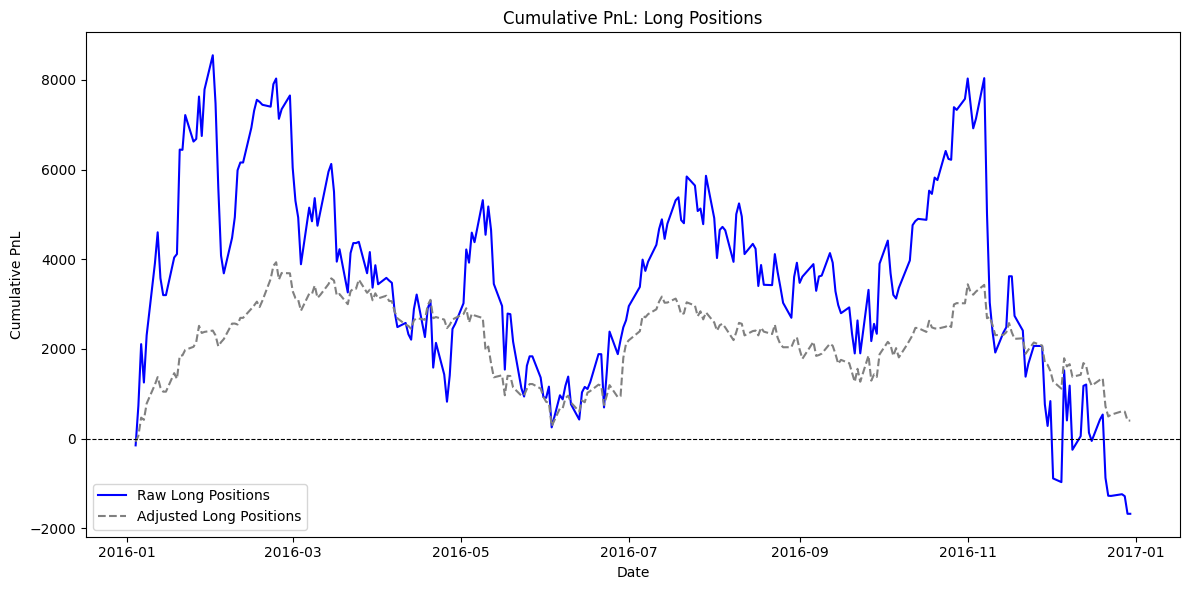

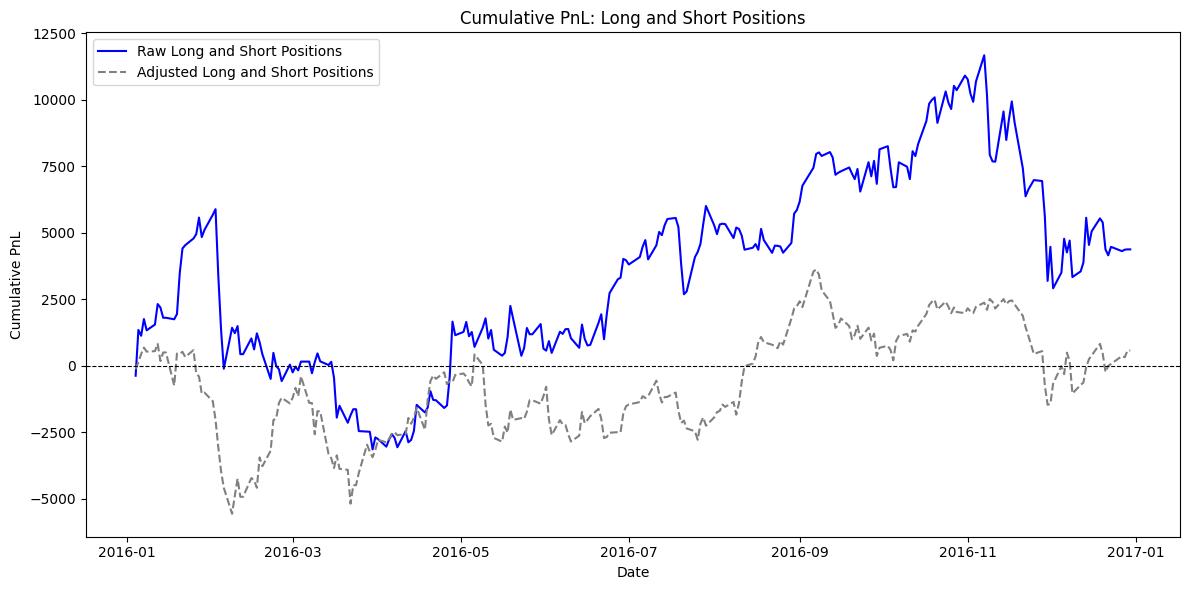

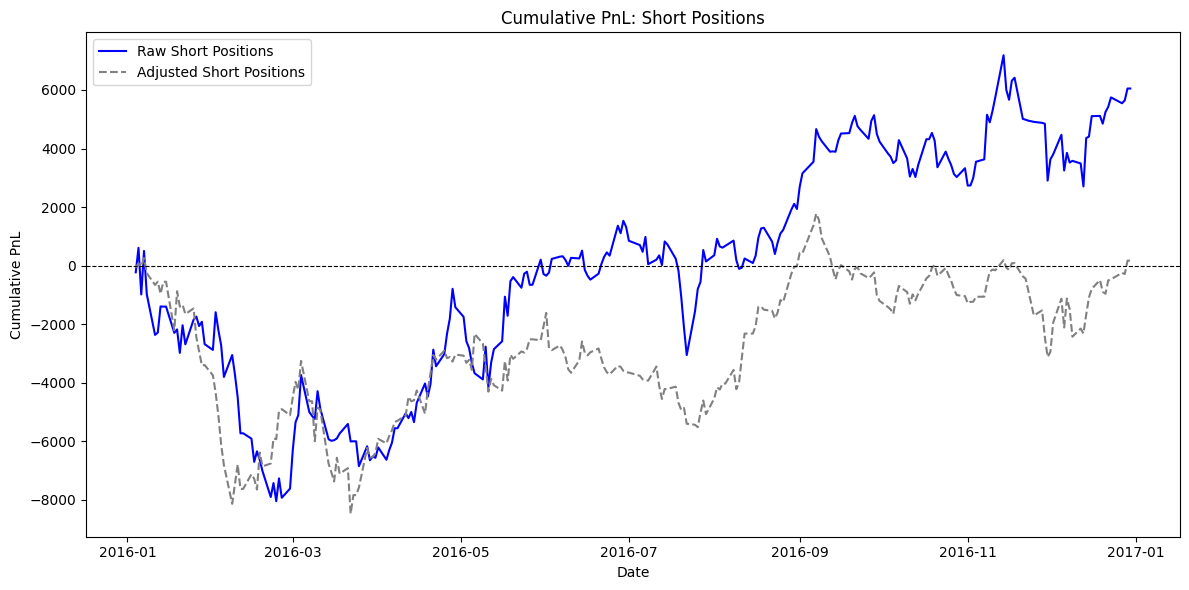

In [19]:
# Plot cumulative PnL for each category
plot_cumulative_pnl(long_data_adj, 'Long Positions', 'grey')
plot_cumulative_pnl(long_and_short_data_adj, 'Long and Short Positions', 'grey')
plot_cumulative_pnl(short_data_adj, 'Short Positions', 'grey')


In [40]:
# Create copies of the data to avoid SettingWithCopyWarning
long_data_adj = long_data_adj.copy()
short_data_adj = short_data_adj.copy()
long_and_short_data_adj = long_and_short_data_adj.copy()

# Calculate raw and adjusted PnL for each category
long_data_adj['PnL_raw'] = long_data_adj['Exposure'] * long_data_adj['Lagged_Return']
long_data_adj['PnL_adj'] = long_data_adj['Adjusted_Exposure'] * long_data_adj['Lagged_Return']

short_data_adj['PnL_raw'] = short_data_adj['Exposure'] * short_data_adj['Lagged_Return']
short_data_adj['PnL_adj'] = short_data_adj['Adjusted_Exposure'] * short_data_adj['Lagged_Return']

long_and_short_data_adj['PnL_raw'] = long_and_short_data_adj['Exposure'] * long_and_short_data_adj['Lagged_Return']
long_and_short_data_adj['PnL_adj'] = long_and_short_data_adj['Adjusted_Exposure'] * long_and_short_data_adj['Lagged_Return']

# Calculate Sharpe ratios
sharpe_long_raw_ = sharpe_ratio(long_data_adj['PnL_raw'])
sharpe_long_adj_ = sharpe_ratio(long_data_adj['PnL_adj'])

sharpe_short_raw_ = sharpe_ratio(short_data_adj['PnL_raw'])
sharpe_short_adj_ = sharpe_ratio(short_data_adj['PnL_adj'])

sharpe_ls_raw_ = sharpe_ratio(long_and_short_data_adj['PnL_raw'])
sharpe_ls_adj_ = sharpe_ratio(long_and_short_data_adj['PnL_adj'])

# Create summary table
summary_table_t = pd.DataFrame({
    'Category': ['Long Raw', 'Long Adjusted', 'L/S Raw', 'L/S Adjusted', 'Short Raw', 'Short Adjusted'],
    'Sharpe Ratio': [sharpe_long_raw_, sharpe_long_adj_, sharpe_ls_raw_, sharpe_ls_adj_, sharpe_short_raw_, sharpe_short_adj_]
})

#summary_table_t

# Force the display format for 'Sharpe Ratio' to 4 decimals
summary_table_t['Sharpe Ratio'] = summary_table_t['Sharpe Ratio'].map('{:.4f}'.format)

# Display the summary table
print(summary_table_t)


         Category Sharpe Ratio
0        Long Raw      -0.0033
1   Long Adjusted       0.0027
2         L/S Raw       0.0030
3    L/S Adjusted       0.0007
4       Short Raw       0.0075
5  Short Adjusted       0.0003


## Earnings Season Analysis 

In [21]:
industry_total_pnl_ = industry_total_pnl.copy()
industry_total_pnl_

,Date,Industry_PnL,Cumulative_pnl,Peak_Cumulative_PnL,Drawdown,Rolling_Mean,Rolling_StdDev,Sharpe_Ratio
0,2016-01-04,-0.00,-376.56,-376.56,0.00,NaN,NaN,NaN
1,2016-01-05,0.00,1345.55,1345.55,0.00,NaN,NaN,NaN
2,2016-01-06,-0.00,1126.07,1345.55,-219.48,NaN,NaN,NaN
3,2016-01-07,0.00,1755.22,1755.22,0.00,NaN,NaN,NaN
4,2016-01-08,-0.00,1329.71,1755.22,-425.51,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
251,2016-12-23,0.00,4469.30,11671.45,-7202.16,-0.00,0.00,-0.12
252,2016-12-27,-0.00,4307.15,11671.45,-7364.30,-0.00,0.00,-0.12
253,2016-12-28,0.00,4362.71,11671.45,-7308.74,-0.00,0.00,-0.06
254,2016-12-29,0.00,4373.68,11671.45,-7297.77,0.00,0.00,0.07


In [22]:
# Define earnings season date ranges
earnings_seasons = [
    ("2016-01-11", "2016-02-19"),
    ("2016-04-11", "2016-05-20"),
    ("2016-07-11", "2016-08-19"),
    ("2016-10-10", "2016-11-18"),
]

In [23]:
# Convert the `date` column to datetime if not already
industry_total_pnl_['Date'] = pd.to_datetime(industry_total_pnl_['Date'])


In [24]:
# Initialize earnings_indicator column with 0
industry_total_pnl_['earnings_indicator'] = 0

In [25]:
# Set earnings_indicator to 1 for dates within any earnings season
for start, end in earnings_seasons:
    industry_total_pnl_.loc[(industry_total_pnl_['Date'] >= pd.to_datetime(start)) & (industry_total_pnl_['Date'] <= pd.to_datetime(end)), 'earnings_indicator'] = 1

In [26]:
industry_total_pnl_.head(10)

,Date,Industry_PnL,Cumulative_pnl,Peak_Cumulative_PnL,Drawdown,Rolling_Mean,Rolling_StdDev,Sharpe_Ratio,earnings_indicator
0,2016-01-04,-0.00,-376.56,-376.56,0.00,NaN,NaN,NaN,0
1,2016-01-05,0.00,1345.55,1345.55,0.00,NaN,NaN,NaN,0
2,2016-01-06,-0.00,1126.07,1345.55,-219.48,NaN,NaN,NaN,0
3,2016-01-07,0.00,1755.22,1755.22,0.00,NaN,NaN,NaN,0
4,2016-01-08,-0.00,1329.71,1755.22,-425.51,NaN,NaN,NaN,0
5,2016-01-11,0.00,1547.26,1755.22,-207.96,NaN,NaN,NaN,1
6,2016-01-12,0.00,2317.89,2317.89,0.00,NaN,NaN,NaN,1
7,2016-01-13,-0.00,2186.21,2317.89,-131.68,NaN,NaN,NaN,1
8,2016-01-14,-0.00,1803.18,2317.89,-514.71,NaN,NaN,NaN,1
9,2016-01-15,0.00,1803.18,2317.89,-514.71,NaN,NaN,NaN,1


In [27]:
# Idea 1: Performance During Earnings Seasons vs. Non-Earnings Periods
performance_summary_ = industry_total_pnl_.groupby('earnings_indicator')['Industry_PnL'].agg(['mean', 'std', 'count']).reset_index()
performance_summary_.rename(columns={'mean': 'Average PnL', 'std': 'Std Dev PnL', 'count': 'Sample Size'}, inplace=True)

# Idea 2: Sharpe Ratio Differentiation
sharpe_ratios_ = industry_total_pnl_.groupby('earnings_indicator').apply(
    lambda x: x['Industry_PnL'].mean() / x['Industry_PnL'].std() if x['Industry_PnL'].std() != 0 else 0
).reset_index(name='Sharpe Ratio')

# Idea 3: Impact of Earnings Season on Drawdowns
drawdown_analysis_ = industry_total_pnl_.groupby('earnings_indicator')['Drawdown'].agg(['mean', 'min']).reset_index()
drawdown_analysis_.rename(columns={'mean': 'Average Drawdown', 'min': 'Maximum Drawdown'}, inplace=True)

# Idea 4: PnL Attribution During Earnings Periods
industry_pnl_attribution_ = industry_total_pnl_.groupby(['earnings_indicator'])['Industry_PnL'].sum().reset_index()
industry_pnl_attribution_.rename(columns={'Industry_PnL': 'Total PnL'}, inplace=True)

# Display the results
print("Performance Summary During Earnings:")
print(performance_summary_)
print("\nSharpe Ratios During Earnings:")
print(sharpe_ratios_)
print("\nDrawdown Analysis During Earnings:")
print(drawdown_analysis_)
print("\nPnL Attribution During Earnings Periods:")
print(industry_pnl_attribution_)


Performance Summary During Earnings:
   earnings_indicator  Average PnL  Std Dev PnL  Sample Size
0                   0        -0.00         0.00          136
1                   1         0.00         0.00          120

Sharpe Ratios During Earnings:
   earnings_indicator  Sharpe Ratio
0                   0         -0.02
1                   1          0.07

Drawdown Analysis During Earnings:
   earnings_indicator  Average Drawdown  Maximum Drawdown
0                   0          -4409.16          -9033.62
1                   1          -2593.93          -8763.17

PnL Attribution During Earnings Periods:
   earnings_indicator  Total PnL
0                   0      -0.00
1                   1       0.01


/var/folders/18/blnm1nm50696kqjfj926l25r0000gn/T/ipykernel_83789/1124922863.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sharpe_ratios_ = industry_total_pnl_.groupby('earnings_indicator').apply(


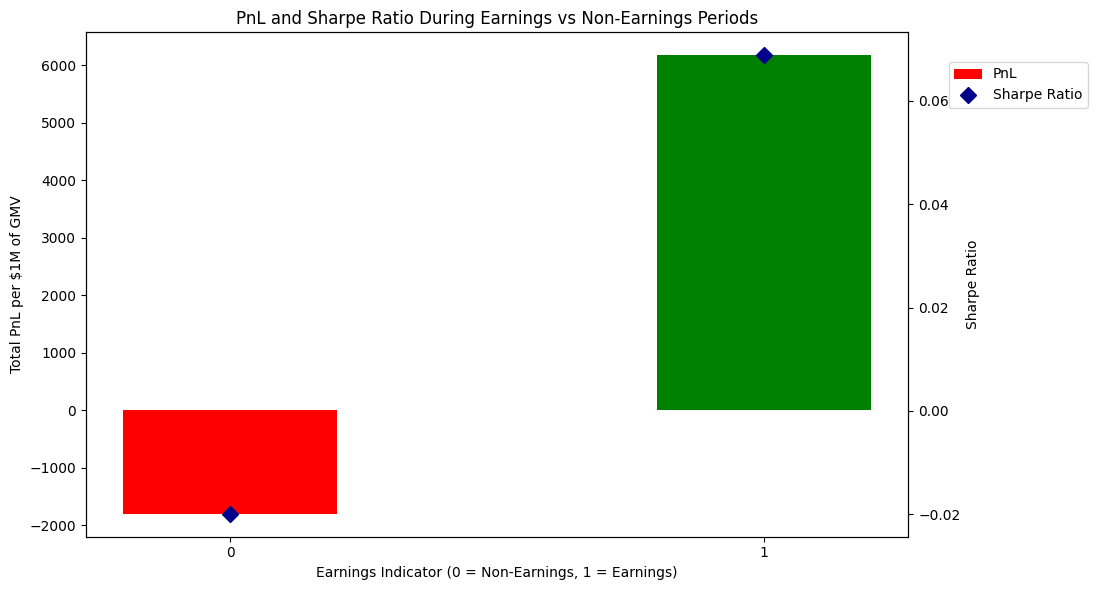

In [28]:
# Merge Sharpe ratios and PnL attribution into one DataFrame for plotting
combined_data = pd.merge(
    sharpe_ratios_.rename(columns={'Sharpe Ratio': 'Sharpe_Ratio'}),
    industry_pnl_attribution_,
    on='earnings_indicator'
    )

combined_data.rename(columns={'Total PnL': 'PnL'}, inplace=True)

# Create a bar chart for PnL and overlay Sharpe Ratios as points
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for PnL
bar_width = 0.4
bar_positions = np.arange(len(combined_data))
ax1.bar(
    bar_positions,
    combined_data['PnL'] * 1000000,
    bar_width,
    color=['red', 'green'],
    label='PnL'
)

ax1.set_xlabel('Earnings Indicator (0 = Non-Earnings, 1 = Earnings)')
ax1.set_ylabel('Total PnL per $1M of GMV', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Secondary axis for Sharpe Ratio
ax2 = ax1.twinx()
ax2.plot(
    bar_positions,
    combined_data['Sharpe_Ratio'],
    'D',
    color='darkblue',
    markersize = 8,
    label='Sharpe Ratio'
    )
ax2.set_ylabel('Sharpe Ratio', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Adjust x-axis ticks and labels
ax1.set_xticks(bar_positions)
ax1.set_xticklabels(combined_data['earnings_indicator'])

# Add title and legend
plt.title('PnL and Sharpe Ratio During Earnings vs Non-Earnings Periods')
fig.tight_layout()
fig.legend(loc='upper right', bbox_to_anchor=(1.1, 0.9))
plt.show()

## Annex

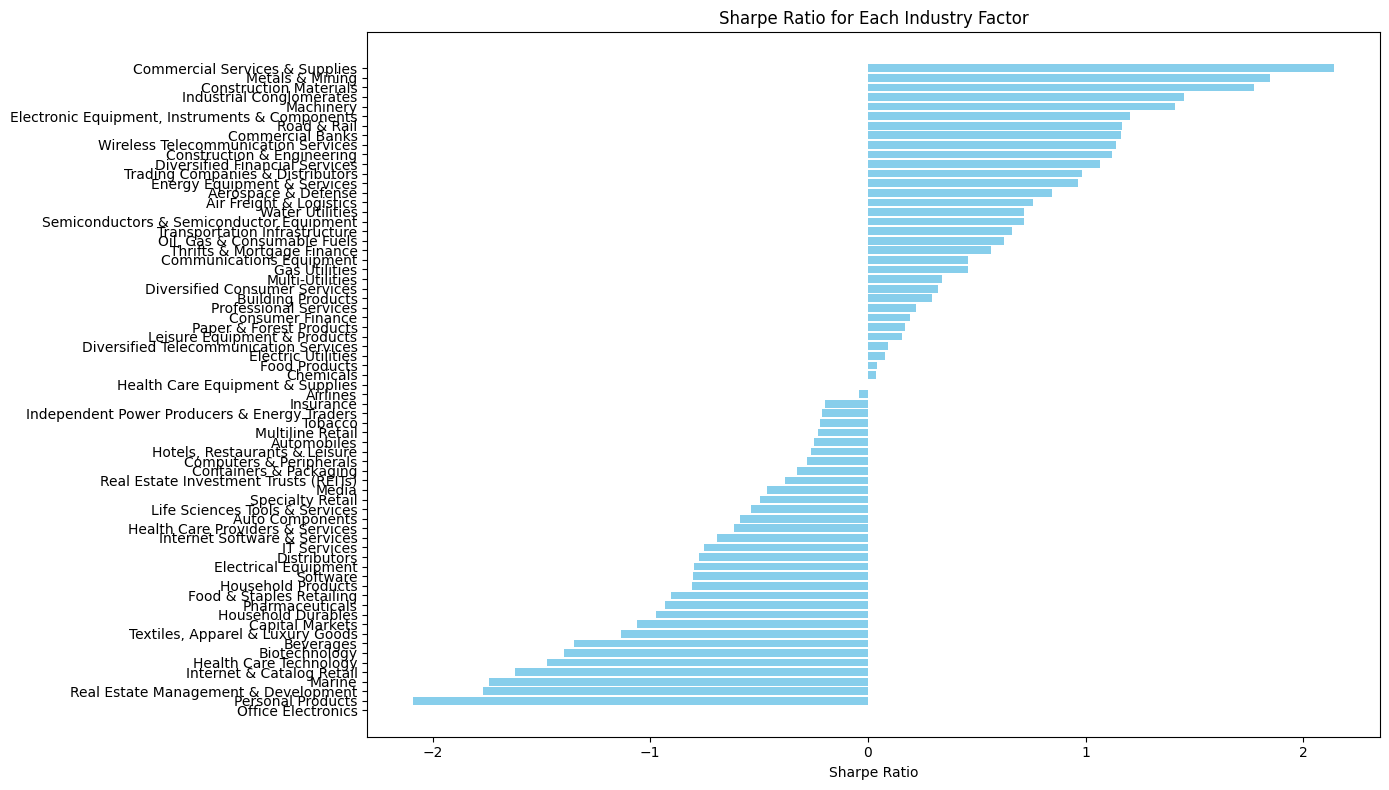

In [29]:
# Calculate the average daily return and annualize it for each factor
average_daily_return = industry_factor_returns.groupby('Industry')['DailyReturn'].mean()
annualized_return = average_daily_return * 252

# Calculate the daily standard deviation of returns and annualize it for each factor
daily_std_dev = industry_factor_returns.groupby('Industry')['DailyReturn'].std()
annualized_std_dev = daily_std_dev * (252 ** 0.5)

# Calculate the Sharpe Ratio for each factor (assuming risk-free rate = 0 for simplicity)
sharpe_ratio = annualized_return / annualized_std_dev

# Create a DataFrame for plotting
sharpe_ratio_df = pd.DataFrame({
    'Industry': sharpe_ratio.index,
    'Sharpe_Ratio': sharpe_ratio.values
})

# Sort the data by Sharpe Ratio for better visualization
sharpe_ratio_df_sorted = sharpe_ratio_df.sort_values(by='Sharpe_Ratio', ascending=False)

# Plotting the Sharpe Ratio for each factor
plt.figure(figsize=(14, 8))
plt.barh(sharpe_ratio_df_sorted['Industry'], sharpe_ratio_df_sorted['Sharpe_Ratio'], color='skyblue')
plt.xlabel('Sharpe Ratio')
plt.title('Sharpe Ratio for Each Industry Factor')
plt.gca().invert_yaxis()  # Invert y-axis to show highest Sharpe ratio at the top
plt.tight_layout()
plt.show()

posx and posy should be finite values
posx and posy should be finite values


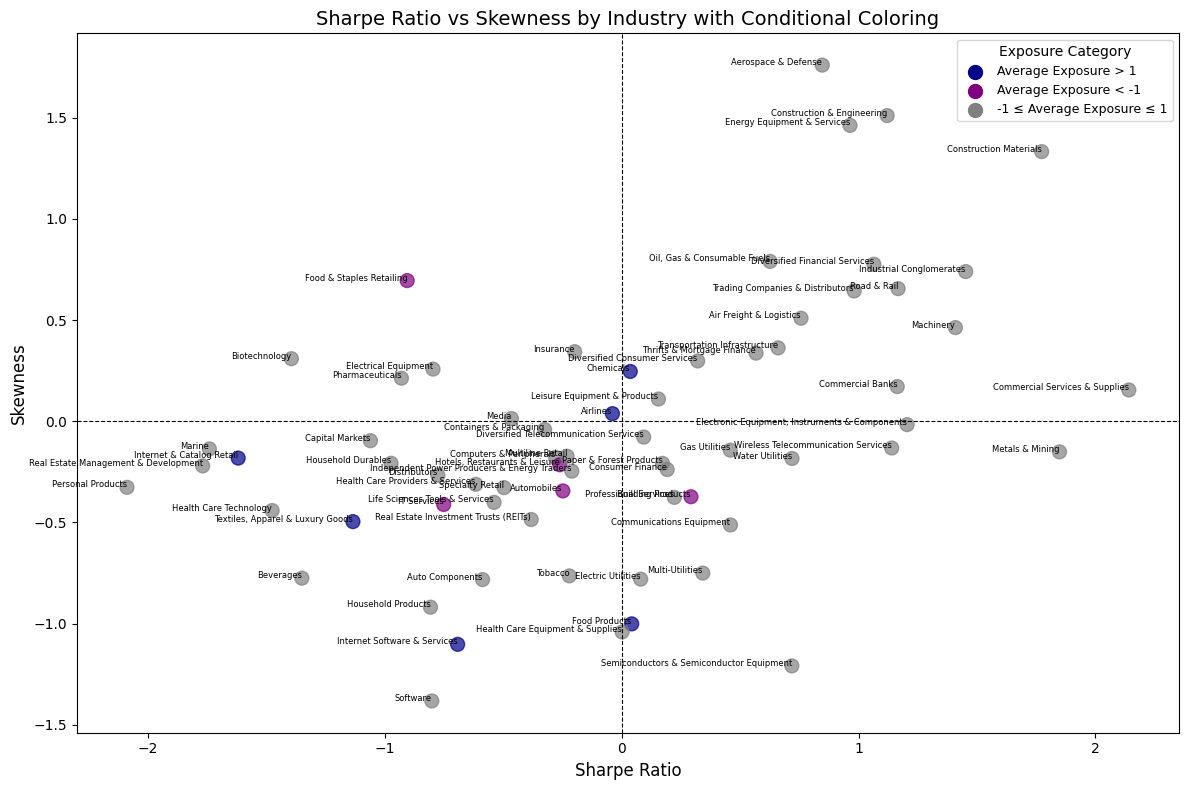

In [56]:
# Step 1: Calculate the average exposure for each industry
average_exposure = industry_exposures.groupby('Industry')['Exposure'].mean()

# Combine Sharpe Ratio, Skewness, and Average Exposure into a single DataFrame
industry_stats = pd.DataFrame({
    'Sharpe Ratio': sharpe_ratio,
    'Skewness': skewness,
    'Average Exposure': average_exposure
}).reset_index()

# Step 2: Define colors based on the conditions
colors = np.where(
    industry_stats['Average Exposure'] > 0.01, 'darkblue', 
    np.where(industry_stats['Average Exposure'] < -0.01, 'purple', 'grey')
)

# Step 3: Create the scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(
    industry_stats['Sharpe Ratio'], 
    industry_stats['Skewness'], 
    c=colors,  # Assign conditional colors
    s=100, 
    alpha=0.7
)

# Add data labels for each industry
for i in range(len(industry_stats)):
    plt.text(
        industry_stats['Sharpe Ratio'][i],
        industry_stats['Skewness'][i],
        industry_stats['Industry'][i],
        fontsize=6,
        ha='right'
    )

# Add titles, labels, and reference lines
plt.title('Sharpe Ratio vs Skewness by Industry with Conditional Coloring', fontsize=14)
plt.xlabel('Sharpe Ratio', fontsize=12)
plt.ylabel('Skewness', fontsize=12)

# Add reference lines
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Horizontal line for Skewness = 0
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)  # Vertical line for Sharpe Ratio = 0

# Add a legend manually
plt.scatter([], [], c='darkblue', s=100, label='Average Exposure > 1')
plt.scatter([], [], c='purple', s=100, label='Average Exposure < -1')
plt.scatter([], [], c='grey', s=100, label='-1 ≤ Average Exposure ≤ 1')
plt.legend(loc='upper right', fontsize=9, title="Exposure Category")

# Display the plot
plt.tight_layout()
plt.show()


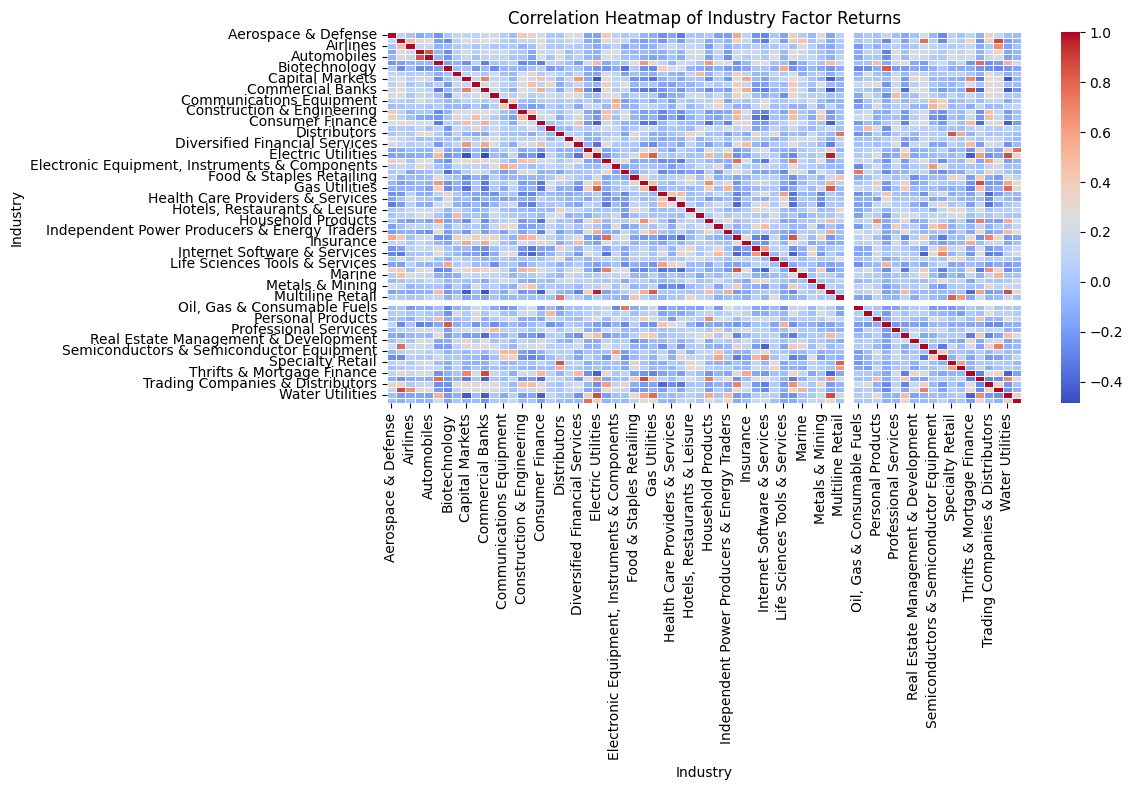

In [31]:
# Pivot the data so industries are columns and dates are rows with DailyReturn as values
returns_pivot = industry_factor_returns.pivot(index='Date', columns='Industry', values='DailyReturn')

# Calculate the correlation matrix across the industries
correlation_matrix = returns_pivot.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Industry Factor Returns')
plt.tight_layout()
plt.show()